In [1]:
import numpy as np, matplotlib.pyplot as plt, sys
from pathlib import Path
sys.path.append(str(Path.home()/ "rugby-video-analytics"))
from phase2.temporal import smooth_sheet, observed_mask, estimate_sigma_m

D = Path.home() / "data/phase2_npz"
STEM = "P9201256"; FUSION_WIN = (3282, 3356)
BODY12 = list(range(5,17))
def load(person, fusion):
    z = np.load(D / f"yolo_raw_{STEM}_{person}_{fusion}.npz")
    return dict(coords=z["coords"], confs=z["confs"], bbox=z["bbox"], frames=z["frame_index"], n_det=z["n_det"])
S={(p,f): load(p,f) for p in ("tackler", "carrier") for f in ("assign", "drop")}
print({k: v["coords"].shape for k, v in S.items()})

{('tackler', 'assign'): (195, 17, 2), ('tackler', 'drop'): (195, 17, 2), ('carrier', 'assign'): (195, 17, 2), ('carrier', 'drop'): (195, 17, 2)}


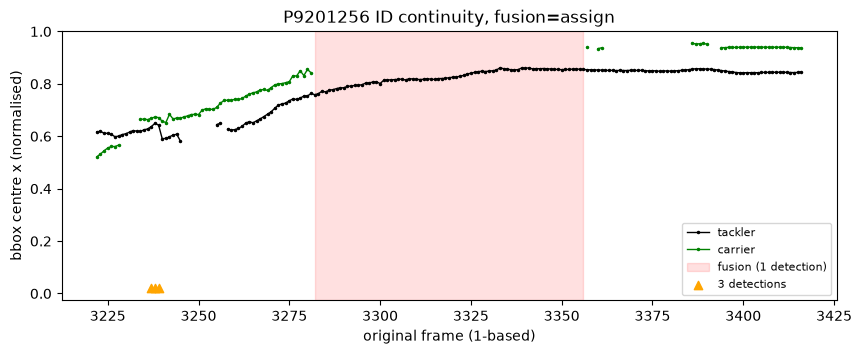

In [2]:
fr = S[("tackler", "assign")]["frames"]; nd = S[("tackler", "assign")]["n_det"]
fig, ax = plt.subplots(figsize=(10, 3.5))
for p, c in (("tackler", "k"), ("carrier", "g")):
    cx = S[(p, "assign")]["bbox"][:, 0].copy(); cx[cx == 0] = np.nan     # missing -> gap in the line
    ax.plot(fr, cx, c, marker=".", ms=3, lw=1, label=p)
ax.axvspan(*FUSION_WIN, color="r", alpha=0.12, label="fusion (1 detection)")
three_detection_mask = nd == 3
ax.scatter(fr[three_detection_mask], np.full(three_detection_mask.sum(), 0.02),
           marker="^", c="orange", label="3 detections")
ax.set(xlabel="original frame (1-based)", ylabel="bbox centre x (normalised)", title=f"{STEM} ID continuity, fusion=assign")
ax.legend(fontsize=8)
plt.show()
figure_path = Path.home() / "rugby-video-analytics" / "phase2" / "results" / "fig_id_continuity_P9201256_assign.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=120)

In [3]:
D2 = Path.home() / "data/phase2_npz/win3162"
CONTACT = 3229          # handover 4.1: single-detection frames start here (contact imminent); impact ≈ 3237
sig_pre = {}
for person in ("tackler", "carrier"):
    z = np.load(D2 / f"yolo_raw_P9201256_{person}_assign.npz")
    pre = z["frame_index"] < CONTACT                     # calm pre-contact segment, both persons fully visible
    c12, k12 = z["coords"][pre][:, BODY12], z["confs"][pre][:, BODY12]
    obs = observed_mask(c12, k12)
    sig_pre[person] = estimate_sigma_m(c12, obs)
    print(person, f"pre-contact frames={int(pre.sum())}", f"sigma_m={sig_pre[person]:.5f}",
          f"(4K x-px ≈ {sig_pre[person]*3840:.1f})", " unobserved joint-frames:", int((~obs).sum()), "/", obs.size,
          " joints unobserved at first frame:", int((~obs[0]).sum()))

tackler pre-contact frames=67 sigma_m=0.00504 (4K x-px ≈ 19.4)  unobserved joint-frames: 60 / 804  joints unobserved at first frame: 2
carrier pre-contact frames=67 sigma_m=0.00147 (4K x-px ≈ 5.7)  unobserved joint-frames: 54 / 804  joints unobserved at first frame: 12


## Temporal Parameters

In [4]:
import json
PARAMS = Path.home() / "rugby-video-analytics" / "phase2" / "results" / "temporal_params_P9201256.json"
params = json.loads(PARAMS.read_text()) if PARAMS.exists() else dict(sigma_a=None, sigma_a_note="pending: run hide-and-predict (step C)")
params.update(
    sigma_m={p: float(v) for p, v in sig_pre.items()},
    sigma_m_segment=[3162, CONTACT - 1], sigma_m_frames=int(pre.sum()))
PARAMS.parent.mkdir(parents=True, exist_ok=True)
PARAMS.write_text(json.dumps(params, indent=2))
print(PARAMS.read_text())

{
  "sigma_m": {
    "tackler": 0.005040327473779988,
    "carrier": 0.001473206968668271
  },
  "sigma_m_segment": [
    3162,
    3228
  ],
  "sigma_m_frames": 67,
  "sigma_a": 1e-05,
  "sigma_a_note": "provisional: RTS-grid minimum on P9201256 visible segments, not evidence of superiority over interpolation; update with the training footage",
  "sigma_a_by_window": {
    "60": {
      "best": 1e-05,
      "n_windows": 11,
      "err": 0.010546404784693087,
      "interp": 0.009316935777953008
    },
    "30": {
      "best": 3e-05,
      "n_windows": 26,
      "err": 0.009645969313921421,
      "interp": 0.007970200603194711
    }
  }
}


In [5]:
import json, importlib
from phase2.scripts.labels_to_sheets import read_frame
import phase2.temporal
importlib.reload(phase2.temporal)
from phase2.temporal import hide_and_predict, estimate_sigma_m, observed_mask

LABELS = Path.home() / "rugby-video-analytics/runs/pose/runs/pose/20260920_full/labels"
GRID = (1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3)

material = []
for seg in ("seg245", "seg839", "seg1619", "seg2827", "win3162"):
    for person in ("tackler", "carrier"):
        f = Path.home() / f"data/phase2_npz/{seg}/yolo_raw_P9201256_{person}_assign.npz"
        if not f.exists():
            print(f"Skipped missing material: {f}")
            continue
        with np.load(f) as z:
            c, k, fr = z["coords"], z["confs"], z["frame_index"]
        if seg == "win3162":
            keep = (fr >= 3162) & (fr < CONTACT)
            c, k = c[keep], k[keep]
        material.append((f"{seg}/{person}", c, k))
frames = np.arange(2931, 3162)
c = np.zeros((len(frames), 17, 2)); k = np.zeros((len(frames), 17))
for i, n in enumerate(frames):
    dets = read_frame(LABELS, "P9201256", int(n))
    if dets:
        c[i], k[i] = dets[0]["kp"], dets[0]["kc"]
material.append(("single2931", c, k))

results = {}
for name, c17, k17 in material:
    c12, k12 = c17[:, BODY12], k17[:, BODY12]
    obs = observed_mask(c12, k12)
    sm = estimate_sigma_m(c12, obs)
    if not np.isfinite(sm) or sm <= 0:
        raise ValueError(f"{name}: sigma_m must be finite and positive, got {sm}")
    row = dict(T=len(c12), sigma_m=float(sm))
    for win in (60, 30):
        err, starts = hide_and_predict(c12, obs, sm, sigma_a_grid=GRID, win=win, n_win=100, seed=0)
        row[win] = dict(err=err, n=len(starts))
    results[name] = row
    print(f"{name:18s} T={row['T']:4d} sigma_m={sm:.4f}  windows60={row[60]['n']:2d}  windows30={row[30]['n']:2d}")
print("Total windows:", {win: sum(row[win]["n"] for row in results.values()) for win in (60, 30)})

seg245/tackler     T= 326 sigma_m=0.0004  windows60= 4  windows30= 8
seg245/carrier     T= 326 sigma_m=0.0005  windows60= 3  windows30= 7
seg839/tackler     T= 173 sigma_m=0.0005  windows60= 1  windows30= 2
seg839/carrier     T= 173 sigma_m=0.0005  windows60= 0  windows30= 1
seg1619/tackler    T= 252 sigma_m=0.0005  windows60= 0  windows30= 0
seg1619/carrier    T= 252 sigma_m=0.0037  windows60= 1  windows30= 2
seg2827/tackler    T= 104 sigma_m=0.0008  windows60= 0  windows30= 1
seg2827/carrier    T= 104 sigma_m=0.0011  windows60= 0  windows30= 0
win3162/tackler    T=  67 sigma_m=0.0050  windows60= 0  windows30= 0
win3162/carrier    T=  67 sigma_m=0.0015  windows60= 0  windows30= 1
single2931         T= 231 sigma_m=0.0006  windows60= 2  windows30= 4
Total windows: {60: 11, 30: 26}


60-frame: n=11, best=1.0e-05, RTS=0.01055, interp=0.00932
30-frame: n=26, best=3.0e-05, RTS=0.00965, interp=0.00797


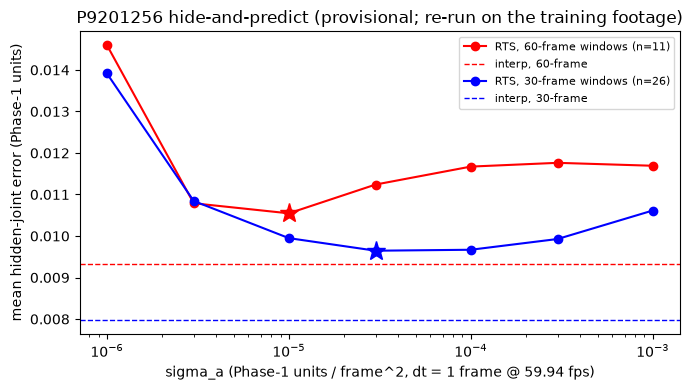

{60: {'best': 1e-05, 'n_windows': 11, 'err': 0.010546404784693087, 'interp': 0.009316935777953008}, 30: {'best': 3e-05, 'n_windows': 26, 'err': 0.009645969313921421, 'interp': 0.007970200603194711}}
Adoption checks passed; minima differ by 1 grid step(s)
{
  "sigma_m": {
    "tackler": 0.005040327473779988,
    "carrier": 0.001473206968668271
  },
  "sigma_m_segment": [
    3162,
    3228
  ],
  "sigma_m_frames": 67,
  "sigma_a": 1e-05,
  "sigma_a_note": "provisional: RTS-grid minimum on P9201256 visible segments, not evidence of superiority over interpolation; update with the training footage",
  "sigma_a_by_window": {
    "60": {
      "best": 1e-05,
      "n_windows": 11,
      "err": 0.010546404784693087,
      "interp": 0.009316935777953008
    },
    "30": {
      "best": 3e-05,
      "n_windows": 26,
      "err": 0.009645969313921421,
      "interp": 0.007970200603194711
    }
  }
}
sigma_m floor = 0.00051  from 9 series  -> smoothing scale ~ 7.1 frames


In [6]:
def pooled(win):
    names = [name for name, row in results.items() if row[win]["n"] > 0]
    if not names:
        raise ValueError(f"No eligible {win}-frame windows; parameters were not updated")
    weights = np.array([results[name][win]["n"] for name in names], float)
    curve = {sa: float(np.average([results[name][win]["err"][sa] for name in names], weights=weights)) for sa in GRID}
    interp = float(np.average([results[name][win]["err"]["interp"] for name in names], weights=weights))
    if not np.isfinite([*curve.values(), interp]).all():
        raise ValueError(f"Non-finite errors for {win}-frame windows; parameters were not updated")
    return curve, interp, int(weights.sum())


def validate_adoption(summary):
    if summary[60]["n_windows"] < 10:
        raise ValueError(f"Only {summary[60]['n_windows']} 60-frame windows; need at least 10; parameters were not updated")
    for win in (60, 30):
        if summary[win]["best"] in (GRID[0], GRID[-1]):
            raise ValueError(f"{win}-frame minimum is at grid boundary {summary[win]['best']}; expand GRID; parameters were not updated")
    steps = abs(GRID.index(summary[60]["best"]) - GRID.index(summary[30]["best"]))
    if steps >= 2:
        raise ValueError(f"Minima differ by {steps} grid steps: 60={summary[60]['best']}, 30={summary[30]['best']}; review both before adoption; parameters were not updated")
    return steps


fig, ax = plt.subplots(figsize=(7, 4)); summary = {}
for win, col in ((60, "r"), (30, "b")):
    curve, interp, n = pooled(win)
    best = min(curve, key=curve.get)
    summary[win] = dict(best=best, n_windows=n, err=curve[best], interp=interp)
    ax.plot(list(curve), list(curve.values()), col + "o-", label=f"RTS, {win}-frame windows (n={n})")
    ax.axhline(interp, color=col, ls="--", lw=1, label=f"interp, {win}-frame")
    ax.plot(best, curve[best], col + "*", ms=14)
    print(f"{win}-frame: n={n}, best={best:.1e}, RTS={curve[best]:.5f}, interp={interp:.5f}")
    if curve[best] >= interp:
        print(f"WARNING: {win}-frame RTS minimum does not outperform linear interpolation")
ax.set(xscale="log", xlabel="sigma_a (Phase-1 units / frame^2, dt = 1 frame @ 59.94 fps)",
       ylabel="mean hidden-joint error (Phase-1 units)",
       title="P9201256 hide-and-predict (provisional; re-run on the training footage)")
ax.legend(fontsize=8); plt.tight_layout()
figure_path = PARAMS.parent / "fig_sigma_a_hide_and_predict_P9201256.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=120); plt.show()
print(summary)
steps = validate_adoption(summary)
print(f"Adoption checks passed; minima differ by {steps} grid step(s)")

params = json.loads(PARAMS.read_text())
params["sigma_a"] = summary[60]["best"]
params["sigma_a_by_window"] = {str(win): summary[win].copy() for win in summary}
params["sigma_a_note"] = "provisional: RTS-grid minimum on P9201256 visible segments, not evidence of superiority over interpolation; update with the training footage"
PARAMS.write_text(json.dumps(params, indent=2)); print(PARAMS.read_text())

calm = {n: r["sigma_m"] for n, r in results.items() if not n.startswith("win3162")}      # calm segments only (pre-contact excluded)
SM_FLOOR = float(np.median(list(calm.values())))
params = json.loads(PARAMS.read_text())
params["sigma_m_pre_contact"] = params.get("sigma_m_pre_contact", params["sigma_m"])        # keep per-person values for the _strong figure
params["sigma_m"] = SM_FLOOR                                                               # decision 10/03: detector floor, common to all
params["sigma_m_rule"] = f"detector floor: median of {len(calm)} calm-segment estimates (pre-contact excluded), common to all persons"
params["sigma_m_floor_series"] = {n: round(v, 5) for n, v in calm.items()}
PARAMS.write_text(json.dumps(params, indent=2))
print(f"sigma_m floor = {SM_FLOOR:.5f}  from {len(calm)} series  -> smoothing scale ~ {np.sqrt(SM_FLOOR / params['sigma_a']):.1f} frames")

In [7]:
import json
PARAMS = Path.home() / "rugby-video-analytics" / "phase2" / "results" / "temporal_params_P9201256.json"
params = json.loads(PARAMS.read_text())
SIGMA_A = params["sigma_a"]
if SIGMA_A is None or not np.isfinite(SIGMA_A) or SIGMA_A <= 0:
    raise ValueError("Select a finite, positive sigma_a in Step C before running Step D")
out, out_strong = {}, {}
for key, s in S.items():
    c12, k12 = s["coords"][:, BODY12], s["confs"][:, BODY12]
    obs = observed_mask(c12, k12)
    sm = params["sigma_m"]                                    # detector floor, common (decision 10/03)
    sm_strong = params["sigma_m_pre_contact"][key[0]]         # per-person pre-contact value -> "_strong" figure
    out[key] = dict(obs=obs, sigma_m=sm, **smooth_sheet(c12, k12, SIGMA_A, sm))
    out_strong[key] = dict(obs=obs, sigma_m=sm_strong, **smooth_sheet(c12, k12, SIGMA_A, sm_strong))
    print(key, f"sigma_m = {sm:.5f}", f"sigma_m_strong = {sm_strong:.5f}", " observed joint-frames:", int(obs.sum()), "/", obs.size)

('tackler', 'assign') sigma_m = 0.00051 sigma_m_strong = 0.00504  observed joint-frames: 1939 / 2340


('tackler', 'drop') sigma_m = 0.00051 sigma_m_strong = 0.00504  observed joint-frames: 892 / 2340
('carrier', 'assign') sigma_m = 0.00051 sigma_m_strong = 0.00147  observed joint-frames: 682 / 2340
('carrier', 'drop') sigma_m = 0.00051 sigma_m_strong = 0.00147  observed joint-frames: 557 / 2340


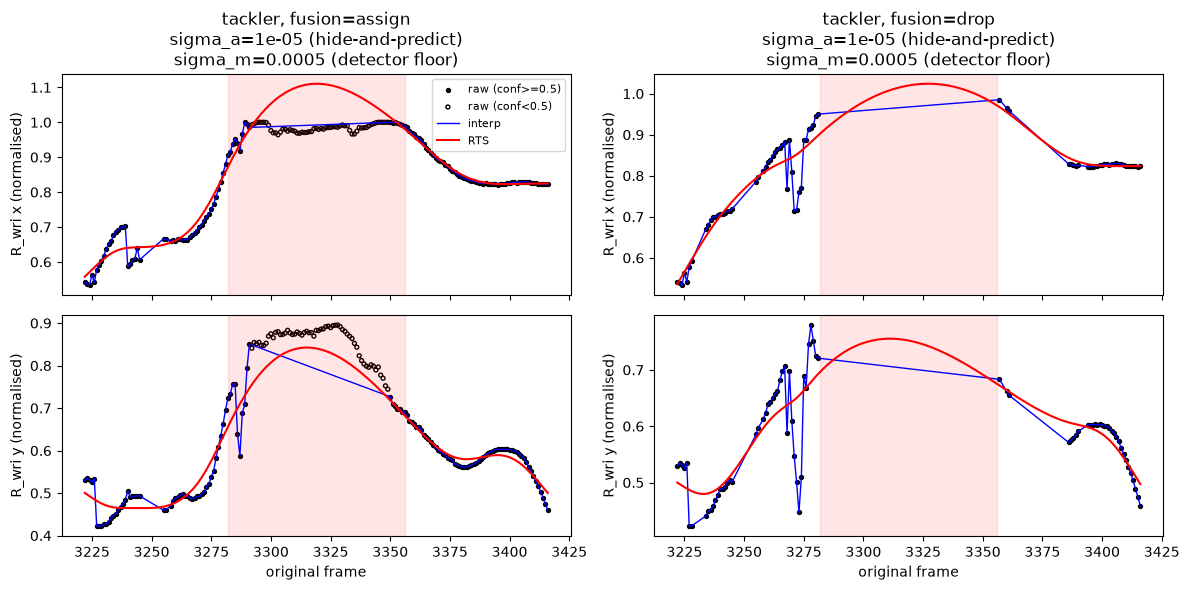

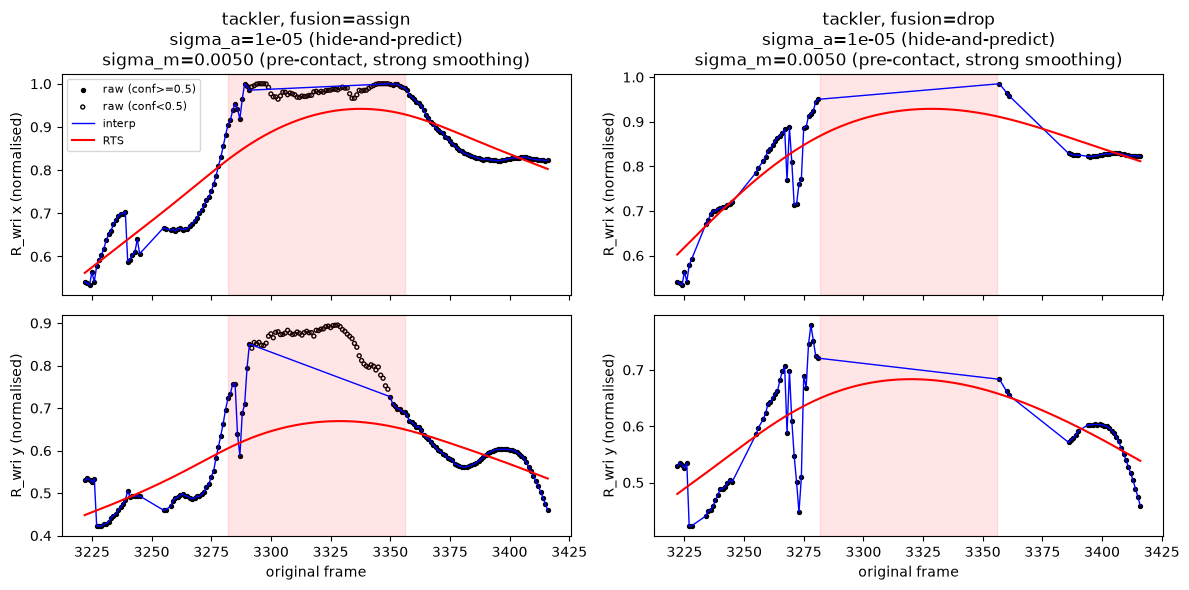

In [8]:
def plot_fig1(o_all, tag, fname):
    J = 5
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    for col, fus in enumerate(("assign", "drop")):
        s, o = S[("tackler", fus)], o_all[("tackler", fus)]
        fr = s["frames"]
        z = s["coords"][:, BODY12[J]]
        ob = o["obs"][:, J]
        has = z[:, 0] != 0
        for row, name in enumerate("xy"):
            ax = axes[row, col]
            ax.scatter(fr[ob], z[ob, row], s=8, c="k", label="raw (conf>=0.5)")
            ax.scatter(fr[has & ~ob], z[has & ~ob, row], s=8, facecolors="none", edgecolors="k", label="raw (conf<0.5)")
            ax.plot(fr, o["interp"][:, J, row], "b-", lw=1, label="interp")
            ax.plot(fr, o["smooth"][:, J, row], "r-", lw=1.5, label="RTS")
            ax.axvspan(*FUSION_WIN, color="r", alpha=0.10)
            ax.set_ylabel(f"R_wri {name} (normalised)")
            if row == 0:
                ax.set_title(f"tackler, fusion={fus}\nsigma_a={SIGMA_A:.0e} (hide-and-predict)\nsigma_m={o['sigma_m']:.4f} ({tag})")
    axes[1, 0].set_xlabel("original frame")
    axes[1, 1].set_xlabel("original frame")
    axes[0, 0].legend(fontsize=8)
    plt.tight_layout()
    figure_path = PARAMS.parent / fname
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_path, dpi=120)
    plt.show()


plot_fig1(out, "detector floor", "fig_temporal_P9201256_tackler_Rwri.png")
plot_fig1(out_strong, "pre-contact, strong smoothing", "fig_temporal_P9201256_tackler_Rwri_strong.png")

In [9]:
from phase2.metrics import jk_table
NAMES = ["L_sho","R_sho","L_elb","R_elb","L_wri","R_wri","L_hip","R_hip","L_kne","R_kne","L_ank","R_ank"]


def table(person, fus):
    s, o = S[(person, fus)], out[(person, fus)]
    raw12, conf12 = s["coords"][:, BODY12], s["confs"][:, BODY12]  # Raw YOLO confidence defines occlusion for every condition.
    has = s["bbox"][:, 2] > 0  # Track is present in this frame.
    raw_b = np.where(has[:, None, None], raw12, o["interp"])  # Keep raw detections and bridge missing track frames linearly.
    cond = dict(raw=raw_b, interp=o["interp"], kalman=o["filt"], rts=o["smooth"])
    rows = {name: jk_table(coords, conf12) for name, coords in cond.items()}
    print(f"\n{person}, fusion={fus}  T={len(s['frames'])}  missing track frames={int((~has).sum())}  [Jk / Jk_occ, Phase-1 units]")
    print(f"{'joint':6s}" + "".join(f"{name:>16s}" for name in cond) + "   n_occ")
    for k, joint_name in enumerate(NAMES):
        cells = [f"{rows[name][k]['Jk']:.4f}/{rows[name][k]['Jk_occ']:.4f}" for name in cond]
        print(f"{joint_name:6s}" + "".join(f"{cell:>16s}" for cell in cells) + f"   {rows['raw'][k]['n_occ']}")
    mean_cells = [
        f"{np.mean([rows[name][k]['Jk'] for k in range(len(NAMES))]):.4f}/"
        f"{np.mean([rows[name][k]['Jk_occ'] for k in range(len(NAMES))]):.4f}"
        for name in cond
    ]
    mean_n_occ = np.mean([rows["raw"][k]["n_occ"] for k in range(len(NAMES))])
    print(f"{'mean':6s}" + "".join(f"{cell:>16s}" for cell in mean_cells) + f"   {mean_n_occ:.1f}")


table("tackler", "assign")
table("tackler", "drop")


tackler, fusion=assign  T=195  missing track frames=10  [Jk / Jk_occ, Phase-1 units]
joint              raw          interp          kalman             rts   n_occ
L_sho    0.0095/0.0084   0.0084/0.0036   0.0100/0.0076   0.0050/0.0033   46
R_sho    0.0095/0.0066   0.0088/0.0031   0.0111/0.0075   0.0058/0.0034   39
L_elb    0.0143/0.0143   0.0125/0.0102   0.0102/0.0064   0.0057/0.0051   58
R_elb    0.0122/0.0065   0.0116/0.0031   0.0108/0.0077   0.0062/0.0026   26
L_wri    0.0189/0.0230   0.0093/0.0060   0.0168/0.0114   0.0055/0.0054   103
R_wri    0.0127/0.0075   0.0110/0.0028   0.0188/0.0170   0.0061/0.0047   68
L_hip    0.0093/0.0111   0.0091/0.0059   0.0061/0.0006   0.0040/0.0033   11
R_hip    0.0088/0.0061   0.0088/0.0061   0.0065/0.0009   0.0041/0.0024   10
L_kne    0.0136/0.0092   0.0136/0.0092   0.0060/0.0008   0.0035/0.0036   10
R_kne    0.0106/0.0052   0.0106/0.0052   0.0054/0.0007   0.0032/0.0011   10
L_ank    0.0184/0.0109   0.0184/0.0109   0.0070/0.0023   0.0031/0.0036   1

This table measures jitter only; it does not establish correctness. Jk can be reduced arbitrarily by making σ_a smaller (Goodhart's law). Correctness will be judged later against annotations using PCK. The reduction in Jk is not the basis for selecting σ_a; the selection criterion is hide-and-predict (Step C).

σ_m = 0.0005 (detector floor; median of nine calm series, common to all). σ_a = 1e-5 (provisional; to be finalized using solo and bag-tackle footage). The strongly smoothed version with σ_m = 0.0050 is saved as `_strong`.